# Stage 4 — Earth–Mars regime calibration & selection

_Pipeline stage 4 of 14. Self-contained deep dive: the Earth↔Mars complexity calibration rationale (below), then the data-driven selection of the working regimes **regA–regE** written to `selected_regimes_AE.csv`. Uses the canonical `channel_heads` package and on-disk artifacts._

## Calibrating Earth complexity to Mars

Earth and Mars coupling rates are only comparable if the networks are matched in
**drainage density / complexity**. A sweep over stream-initiation thresholds and
Strahler-pruning levels — measuring the Dd of each Earth basin's *convex-hull*
network against the Mars reference — yields three frozen regimes that **bracket** the
martian Dd. Running all three and reporting the spread of Mars results is the
project's calibration-uncertainty estimate.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · The frozen presets (full)

In [2]:
from channel_heads.regimes import REGIMES
pd.DataFrame([r.__dict__ for r in REGIMES.values()])

,name,threshold_km2,pre_remove_max_order,order_gap_to_prune,coupling_n_workers,min_prefilter_px
0,regA,0.20,1,0,4,30.0
1,regB,0.25,1,0,4,30.0
2,regC,0.15,1,0,4,30.0


### 2 · The calibration evidence (the Dd sweep that chose the regimes)

In [3]:
cal = RESULTS_DIR / 'drainage_density_calibration/complexity_calibration'
csv = cal / 'dd_master_sweep_complexity.csv'
if csv.exists():
    s = pd.read_csv(csv)
    print('dd_master_sweep_complexity.csv:', s.shape, '| columns:', list(s.columns)[:10])
    display(s.head(8))

dd_master_sweep_complexity.csv: (5046, 49) | columns: ['basin_id', 'dem_name', 'outlet_node', 'threshold_km2', 'pixel_size_m', 'basin_area_km2', 'n_channelheads_full', 'n_segments_full', 'length_km_full', 'hull_area_km2_full']


,basin_id,dem_name,outlet_node,threshold_km2,pixel_size_m,basin_area_km2,n_channelheads_full,n_segments_full,length_km_full,hull_area_km2_full,...,length_km_ge5,hull_area_km2_ge5,dd_hull_ge5,dd_true_ge5,n_nodes_ge5,max_strahler_ge5,status_ge5,pct_length_ge5,outlet_row,outlet_col
0,inyo_o72,inyo,72,0.01,82.768152,8.494703,415,1239,122.365714,9.649024,...,3.328373,0.650804,5.114248,0.391817,35,1,ok,2.720021,72,0
1,inyo_o88,inyo,88,0.01,82.768152,8.083669,385,1179,115.171185,10.114862,...,3.522310,0.887148,3.970373,0.435732,39,1,ok,3.058326,88,0
2,inyo_o2719,inyo,2719,0.01,82.768152,10.597827,496,1546,153.260927,12.276216,...,3.274006,0.623402,5.251841,0.308932,36,1,ok,2.136230,118,9
3,inyo_o8853,inyo,8853,0.01,82.768152,10.748540,429,1568,154.464720,11.519228,...,4.513092,1.120068,4.029303,0.419880,46,1,ok,2.921762,183,30
4,inyo_o10896,inyo,10896,0.01,82.768152,14.372490,541,2097,208.499896,19.126783,...,8.503609,6.182637,1.375402,0.591659,88,2,ok,4.078472,203,37
5,inyo_o19605,inyo,19605,0.01,82.768152,10.967758,429,1600,160.301684,13.338054,...,6.154254,2.921767,2.106347,0.561122,65,1,ok,3.839170,242,67
6,inyo_o23684,inyo,23684,0.01,82.768152,11.104769,400,1620,161.579926,17.931359,...,4.650226,1.380389,3.368779,0.418759,46,1,ok,2.877973,275,81
7,inyo_o24842,inyo,24842,0.01,82.768152,16.283798,643,2376,236.871899,17.866279,...,7.872302,3.486939,2.257654,0.483444,87,1,ok,3.323443,277,85


fig_mars_vs_earth_at_matched_complexity.png


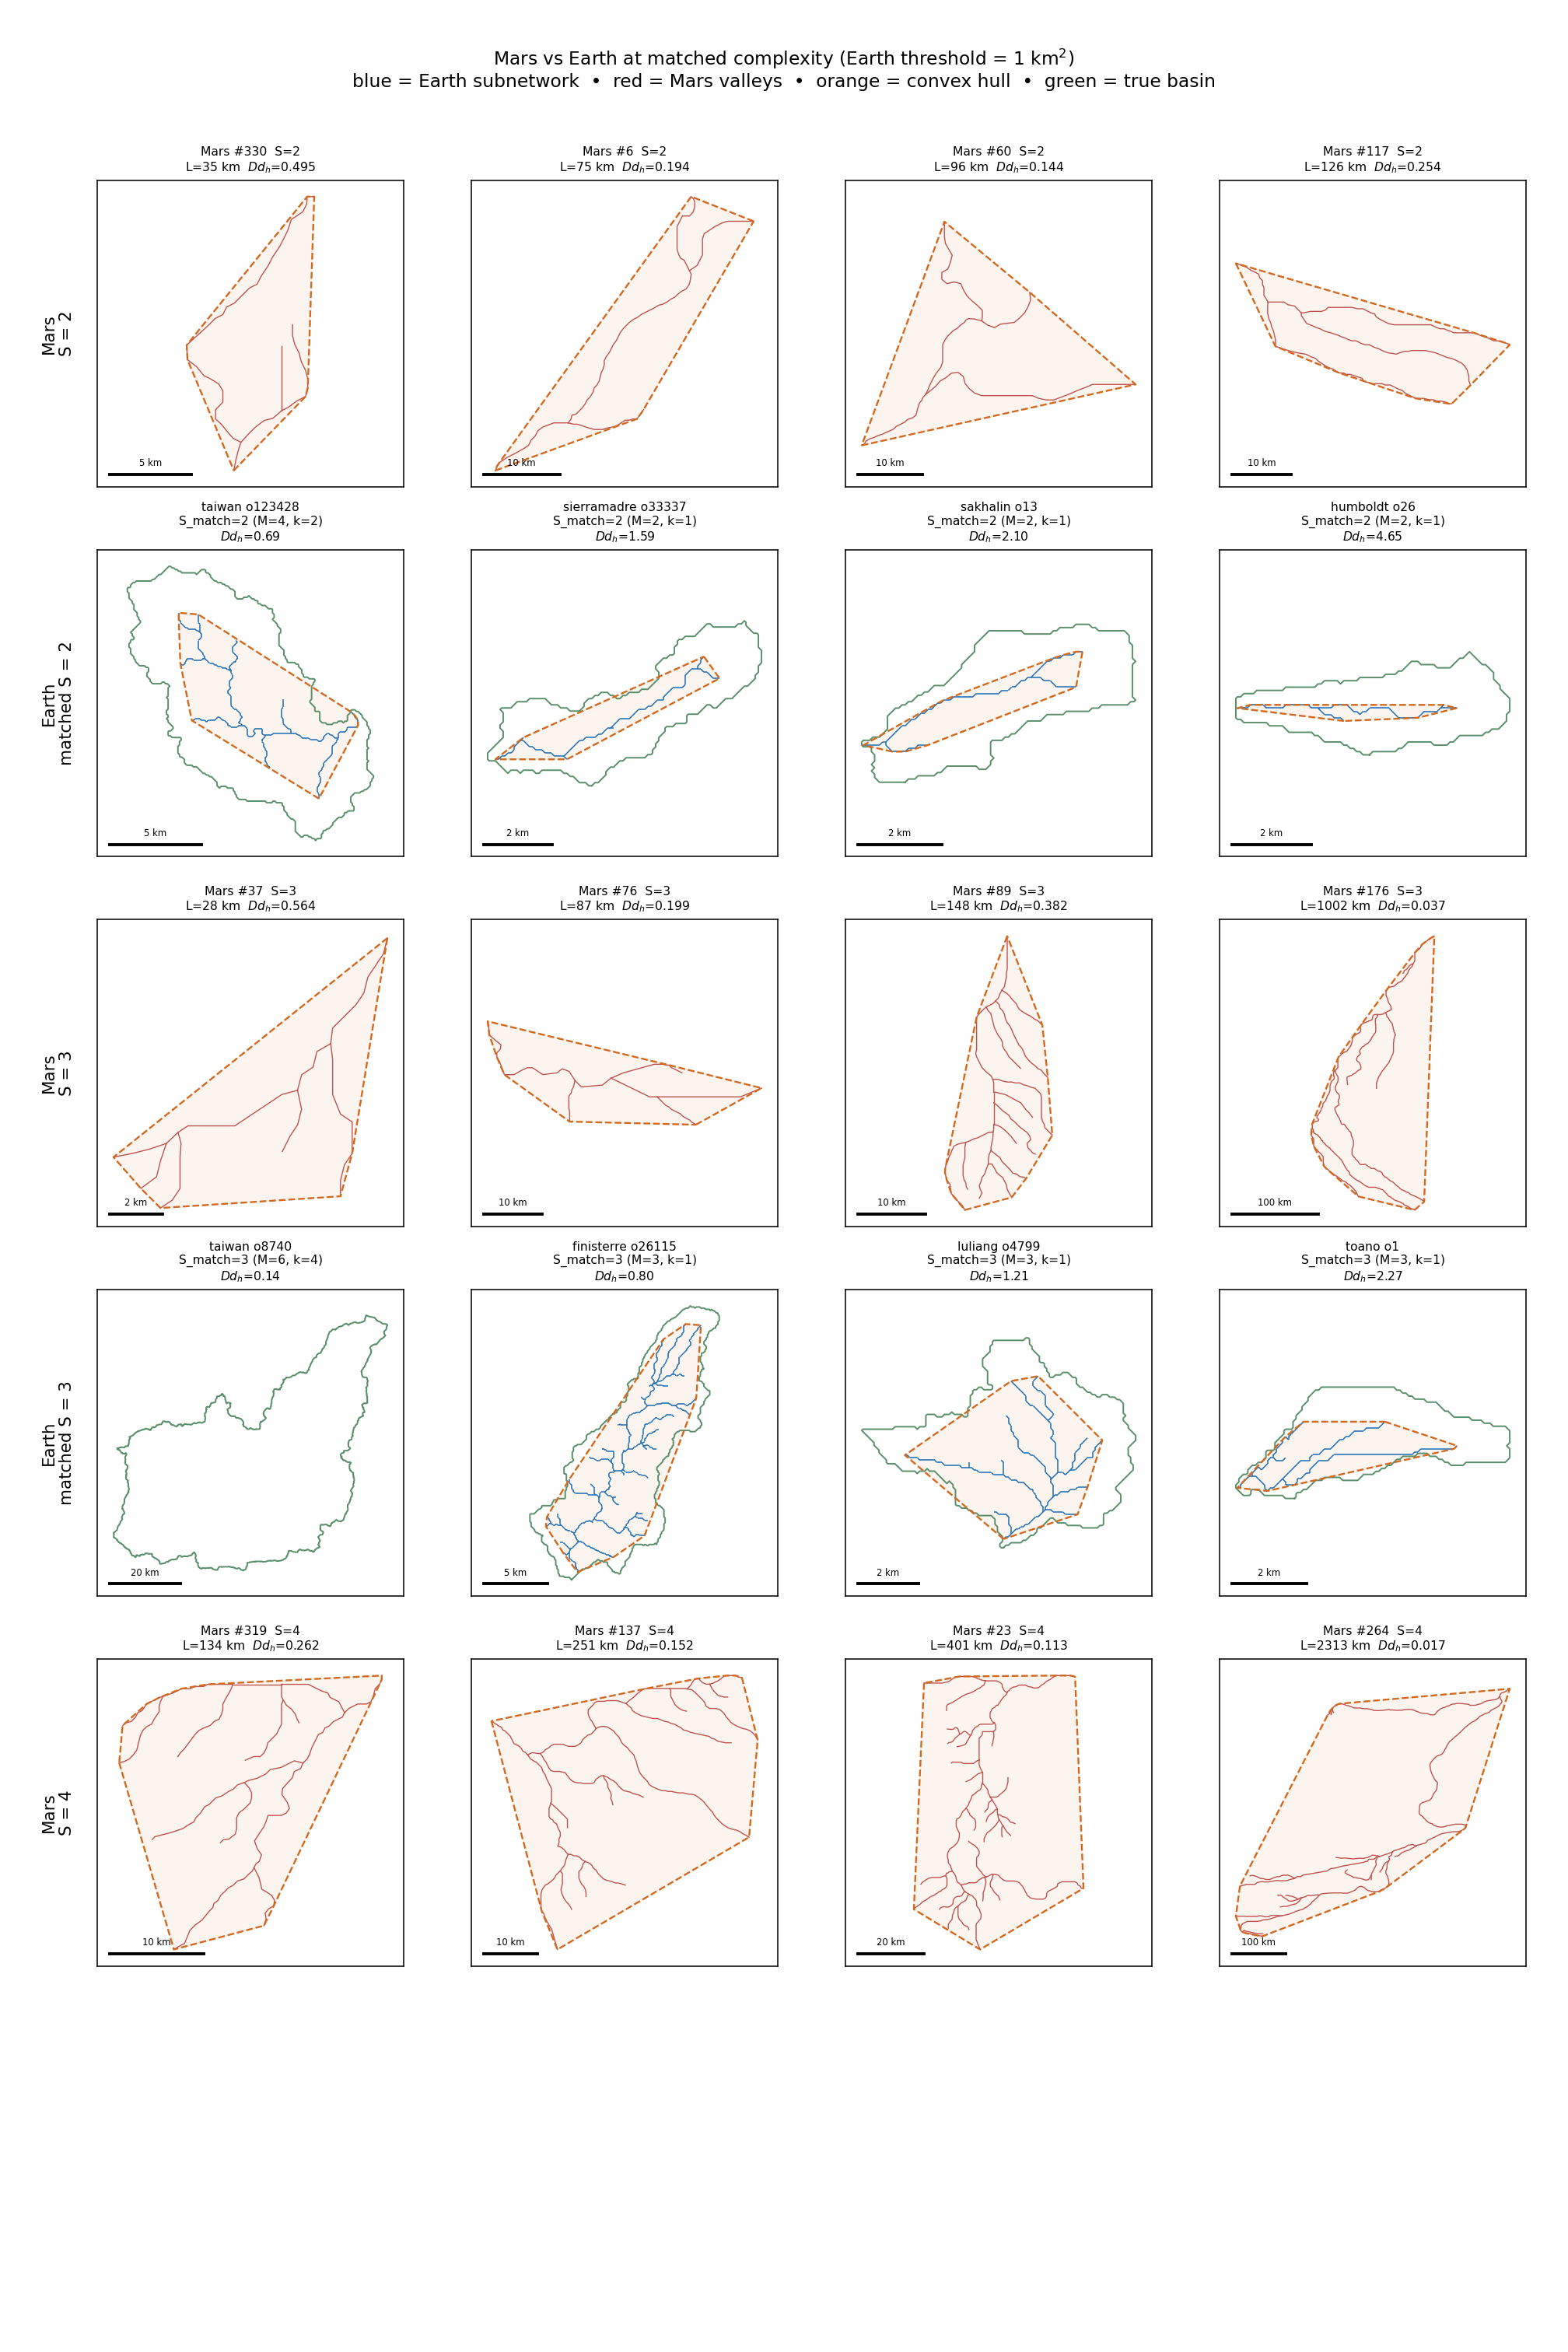

fig_dd_hull_matched_vs_full_vs_mars.png


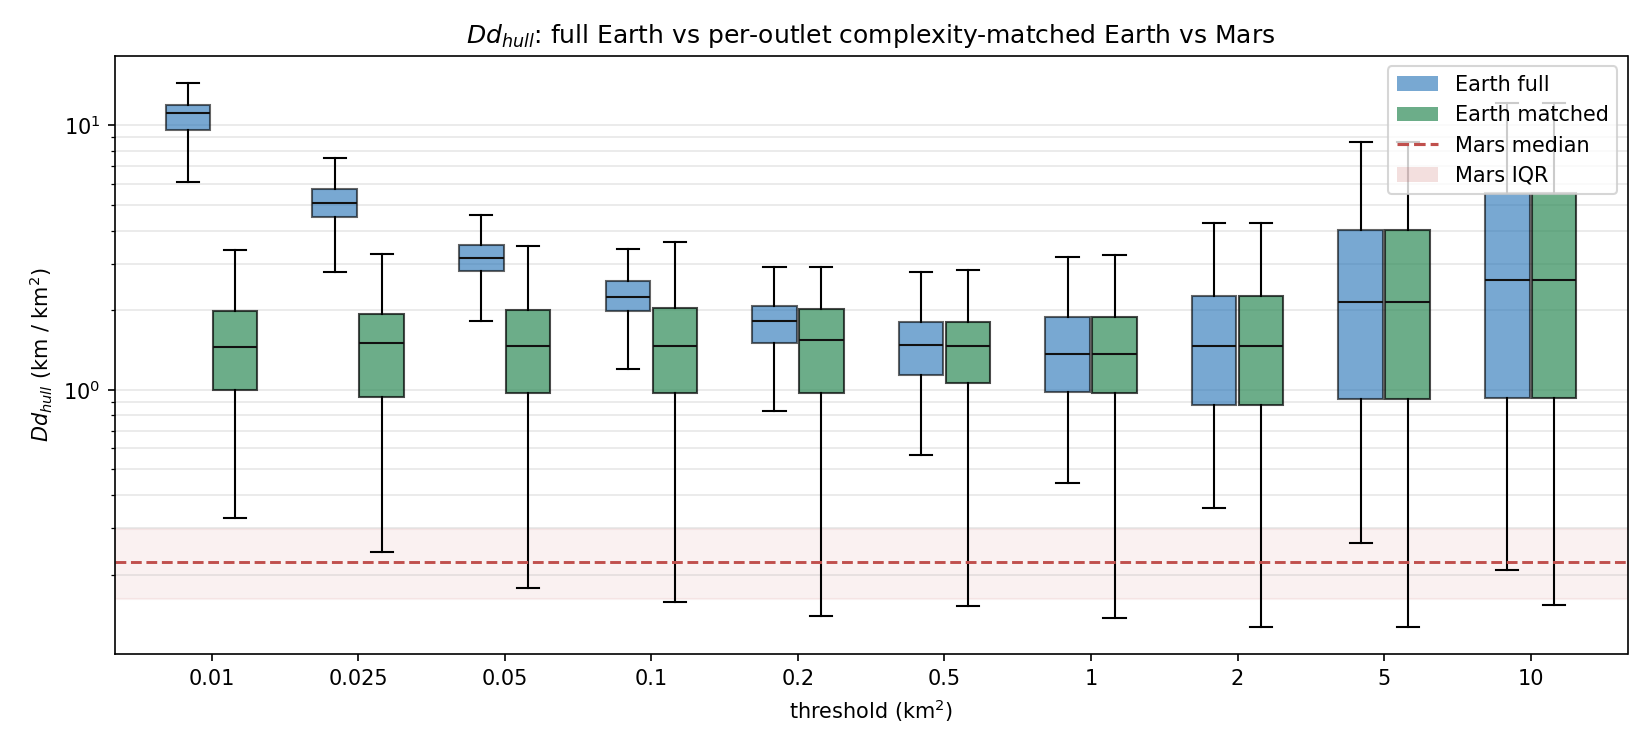

fig_earth_strahler_vs_threshold.png


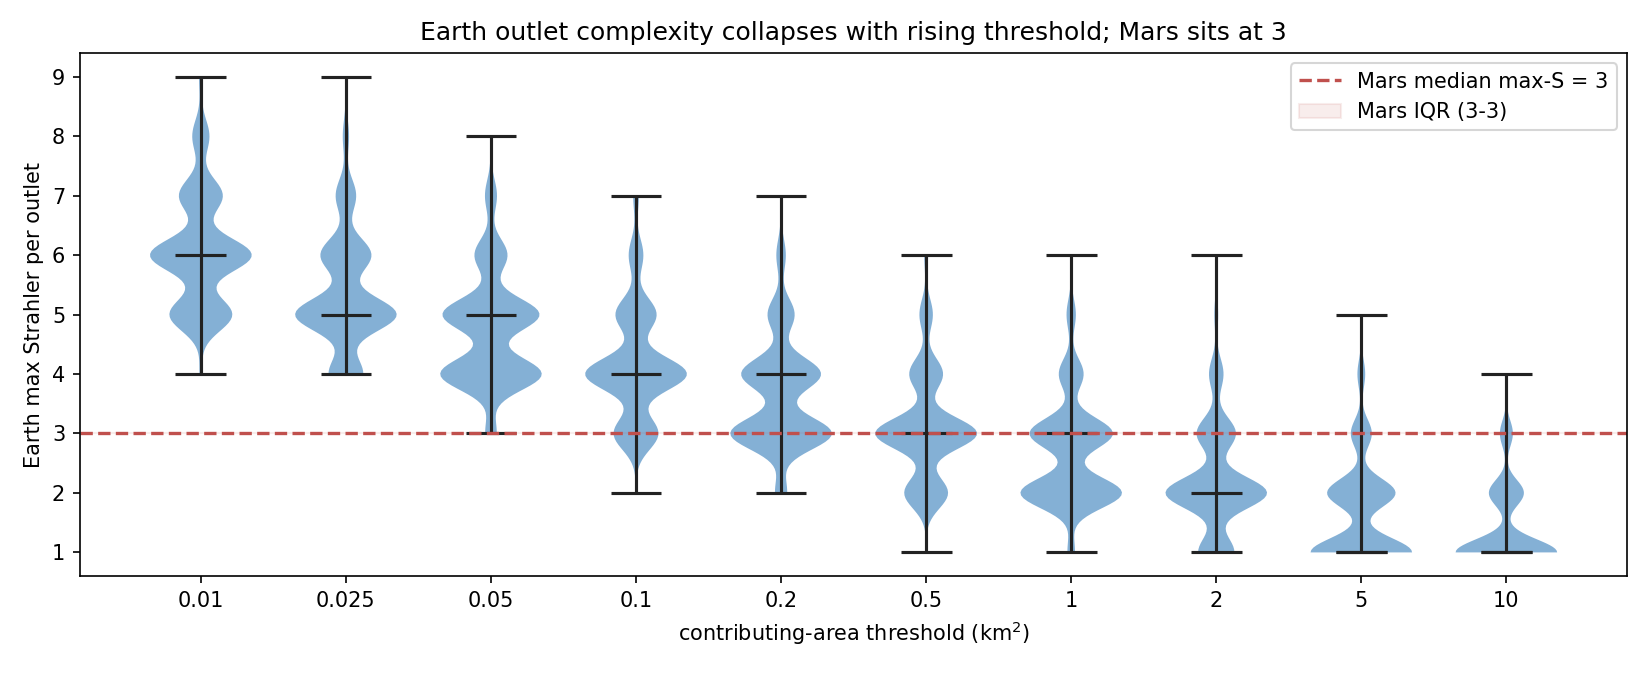

In [4]:
from IPython.display import Image, display
for fig in ['fig_mars_vs_earth_at_matched_complexity.png',
            'fig_dd_hull_matched_vs_full_vs_mars.png',
            'fig_earth_strahler_vs_threshold.png']:
    f = cal / fig
    if f.exists():
        print(fig); display(Image(filename=str(f)))

**Takeaway.** The figures above show Earth networks pulled to the *same* hull-Dd as
Mars; at matched complexity the three regimes sit closest to the martian distribution
(regC densest at 0.15, regA 0.20, regB sparsest at 0.25 km²). These three
threshold/pruning settings (0.20/0.25/0.15 km², plain `trim`, frozen in
`channel_heads.regimes`) propagate unchanged into every trained model and every Mars
prediction downstream — so the only thing that varies across regimes is *complexity*,
and the spread of results is our uncertainty.

> **How these were chosen.** §3 below is the data-driven, eligibility-constrained selection that produced them: the frozen `channel_heads.regimes.REGIMES` (regA/regB/regC) are now the **top-3** of that ranking (the full top-5 regA–regE is in `selected_regimes_AE.csv`, loadable via `channel_heads.regimes.load_selected_regimes`).

## 3 · Regime candidate optimization & selection (regA–regE)

Each candidate regime = `threshold_km2` × order-removal (`pre_remove ∈ {0,1,2}`) × optional **delta** order-gap pruning (`{none,3,4}`). We score every candidate against Mars and keep only **scientifically defensible** ones — hard filters: `length_retained ≥ 0.30`, `median Strahler ≥ 2`, low-order pruning only — then rank by `scientific_score = 0.80·dd + 0.10·complexity + 0.10·length` (lower is better; length is a hard filter so it only tie-breaks). The top **5 distinct** regimes (de-duplicating near-identical delta twins of the same base) become regA…regE.

> The full candidate sweep, Pareto diagnostic, and per-regime valley-network drawings live in the archived `notebooks/archive/regime/03_optimize_regime_candidates.ipynb`. This section recomputes the scoring/selection self-contained from the on-disk per-outlet sweep, so it needs no other notebook.

In [5]:
from channel_heads.dd_calibration import MARS_DD_STATS
from channel_heads.regimes import load_selected_regimes

OPT_DIR = RESULTS_DIR / 'drainage_density_calibration/regime_optimization'
OPT_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_CSV = next((p for p in [
    OPT_DIR / 'dd_master_sweep_delta_low.csv',
    OPT_DIR / 'dd_master_sweep_complexity_dense_low.csv',
    cal / 'dd_master_sweep_complexity.csv',
] if p.exists()), None)
assert SWEEP_CSV is not None, 'no per-outlet sweep CSV found'

LENGTH_FLOOR, COMPLEXITY_FLOOR, LOW_ORDER_MAX_PRE_REMOVE, MAX_THRESHOLD_KM2 = 0.30, 2, 2, 0.5
W_DD, W_CPLX, W_LEN = 0.80, 0.10, 0.10
VARIANT_SPEC = {'full': (0, 0), 'trim': (1, 0), 'ge3': (2, 0),
                'full_d3': (0, 3), 'full_d4': (0, 4), 'trim_d3': (1, 3),
                'trim_d4': (1, 4), 'ge3_d3': (2, 3), 'ge3_d4': (2, 4)}
MARS_DD_MEDIAN = float(MARS_DD_STATS['median'])
_scsv = cal / 'earth_vs_mars_strahler_summary.csv'
MARS_S_MEDIAN = float(pd.read_csv(_scsv)['mars_S_median'].median()) if _scsv.exists() else 3.0

sweep = pd.read_csv(SWEEP_CSV)
sweep = sweep[sweep['threshold_km2'] <= MAX_THRESHOLD_KM2].copy()

def build_scored(df):
    avail = [k for k in VARIANT_SPEC if f'dd_hull_{k}' in df.columns]
    base_ok = df['status_full'].eq('ok') & (df['length_km_full'] > 0)
    rows = []
    for key in avail:
        pre, delta = VARIANT_SPEC[key]
        v_ok = base_ok & df[f'status_{key}'].eq('ok')
        ret = df[f'length_km_{key}'] / df['length_km_full']
        work = df.assign(_r=ret).loc[v_ok]
        for thr, g in work.groupby('threshold_km2'):
            dd = g[f'dd_hull_{key}'].replace([np.inf, -np.inf], np.nan).dropna()
            r = g['_r'].replace([np.inf, -np.inf], np.nan).dropna()
            s = g[f'max_strahler_{key}'].dropna()
            if dd.empty:
                continue
            rows.append(dict(threshold_km2=float(thr), pruning_variant=key,
                pre_remove_max_order=pre, order_gap_to_prune=(delta if delta else pd.NA),
                earth_dd_hull_median=float(dd.median()),
                length_retained_median=float(r.median()) if not r.empty else np.nan,
                max_strahler_median=float(s.median()) if not s.empty else np.nan))
    c = pd.DataFrame(rows)
    c['dd_score'] = (c.earth_dd_hull_median - MARS_DD_MEDIAN).abs() / MARS_DD_MEDIAN
    c['length_score'] = 1.0 - c.length_retained_median
    c['complexity_score'] = (c.max_strahler_median - MARS_S_MEDIAN).abs() / MARS_S_MEDIAN
    return c

candidates = build_scored(sweep)
candidates['eligible'] = ((candidates.length_retained_median >= LENGTH_FLOOR)
                          & (candidates.max_strahler_median >= COMPLEXITY_FLOOR)
                          & (candidates.pre_remove_max_order <= LOW_ORDER_MAX_PRE_REMOVE))
candidates['scientific_score'] = (W_DD * candidates.dd_score + W_CPLX * candidates.complexity_score
                                  + W_LEN * candidates.length_score)
print(f'sweep={SWEEP_CSV.name}: {len(candidates)} candidates, {int(candidates.eligible.sum())} eligible')

sweep=dd_master_sweep_delta_low.csv: 99 candidates, 64 eligible


In [6]:
elig = candidates[candidates.eligible].sort_values(
    ['scientific_score', 'dd_score', 'complexity_score', 'length_retained_median'],
    ascending=[True, True, True, False])
diverse = elig.drop_duplicates(subset=['pre_remove_max_order', 'threshold_km2'], keep='first')
top5 = diverse.head(5).reset_index(drop=True)
top5['name'] = ['regA', 'regB', 'regC', 'regD', 'regE'][:len(top5)]

selected = (top5[['name', 'threshold_km2', 'pre_remove_max_order', 'order_gap_to_prune',
                  'pruning_variant', 'scientific_score', 'dd_score',
                  'length_retained_median', 'complexity_score']]
            .rename(columns={'pruning_variant': 'variant', 'length_retained_median': 'length_retained'}))
selected['order_gap_to_prune'] = selected['order_gap_to_prune'].fillna(0).astype(int)
selected.to_csv(OPT_DIR / 'selected_regimes_AE.csv', index=False)
print('wrote', (OPT_DIR / 'selected_regimes_AE.csv').relative_to(ROOT))
display(selected)

# downstream consumption pattern (foundation): load back as Regime objects
for nm, rg in load_selected_regimes(OPT_DIR / 'selected_regimes_AE.csv').items():
    print(f'  {nm}: T={rg.threshold_km2} km², pre_remove={rg.pre_remove_max_order}, order_gap={rg.order_gap_to_prune}')

wrote data/results/drainage_density_calibration/regime_optimization/selected_regimes_AE.csv


,name,threshold_km2,pre_remove_max_order,order_gap_to_prune,variant,scientific_score,dd_score,length_retained,complexity_score
0,regA,0.20,1,0,trim,3.985830,4.919510,0.497784,0.000000
1,regB,0.25,1,0,trim,4.089317,5.006489,0.492073,0.333333
2,regC,0.15,1,0,trim,4.167550,5.146429,0.495929,0.000000
3,regD,0.30,1,0,trim,4.187509,5.129472,0.494017,0.333333
4,regE,0.40,1,0,trim,4.359827,5.345228,0.496888,0.333333


  regA: T=0.2 km², pre_remove=1, order_gap=0
  regB: T=0.25 km², pre_remove=1, order_gap=0
  regC: T=0.15 km², pre_remove=1, order_gap=0
  regD: T=0.3 km², pre_remove=1, order_gap=0
  regE: T=0.4 km², pre_remove=1, order_gap=0


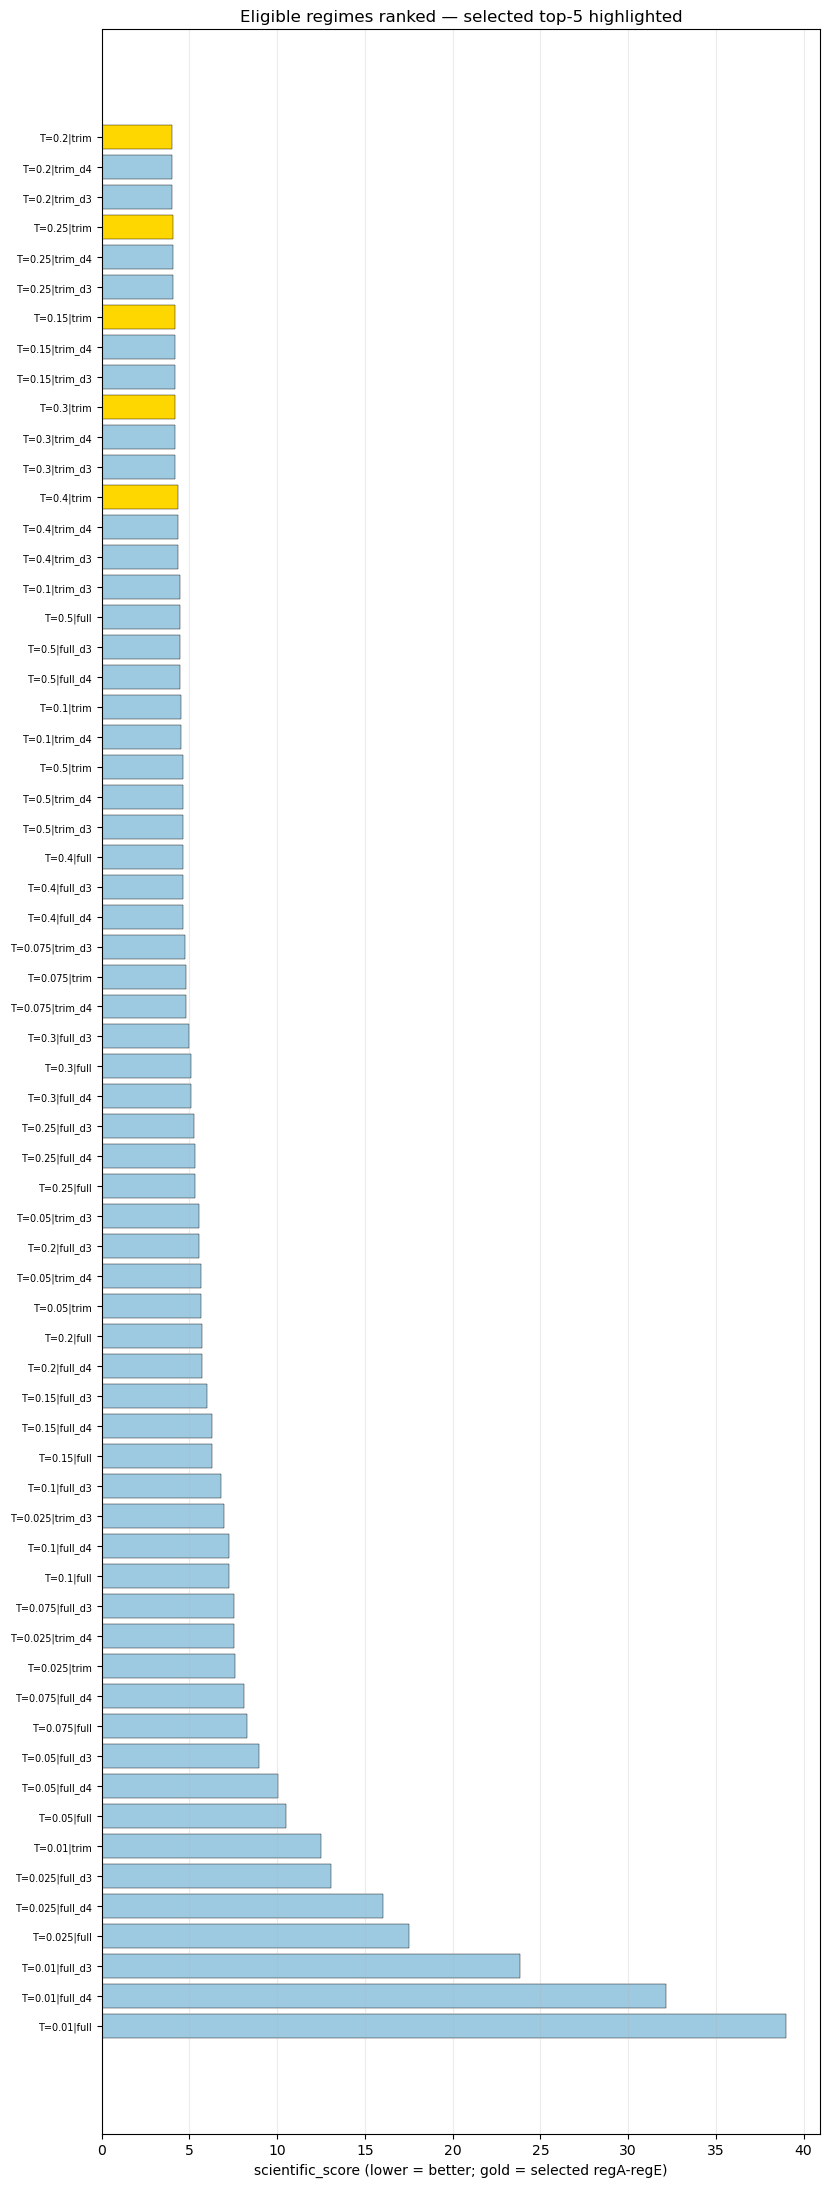

In [7]:
# Figure A — eligible regimes ranked; selected regA-regE in gold.
te = elig.iloc[::-1]
sel_keys = set(zip(top5.pre_remove_max_order, top5.threshold_km2, top5.pruning_variant))
colors = ['gold' if (r.pre_remove_max_order, r.threshold_km2, r.pruning_variant) in sel_keys
          else '#9ecae1' for r in te.itertuples()]
fig, ax = plt.subplots(figsize=(8.4, 0.32 * len(te) + 1.5))
ax.barh(range(len(te)), te.scientific_score, color=colors, edgecolor='k', linewidth=0.3)
ax.set_yticks(range(len(te)))
ax.set_yticklabels([f'T={r.threshold_km2:g}|{r.pruning_variant}' for r in te.itertuples()], fontsize=7)
ax.set_xlabel('scientific_score (lower = better; gold = selected regA-regE)')
ax.set_title('Eligible regimes ranked — selected top-5 highlighted')
ax.grid(True, axis='x', alpha=0.25); fig.tight_layout()
fig.savefig(OPT_DIR / 'fig_selection_ranking.png', dpi=150, bbox_inches='tight'); plt.show()

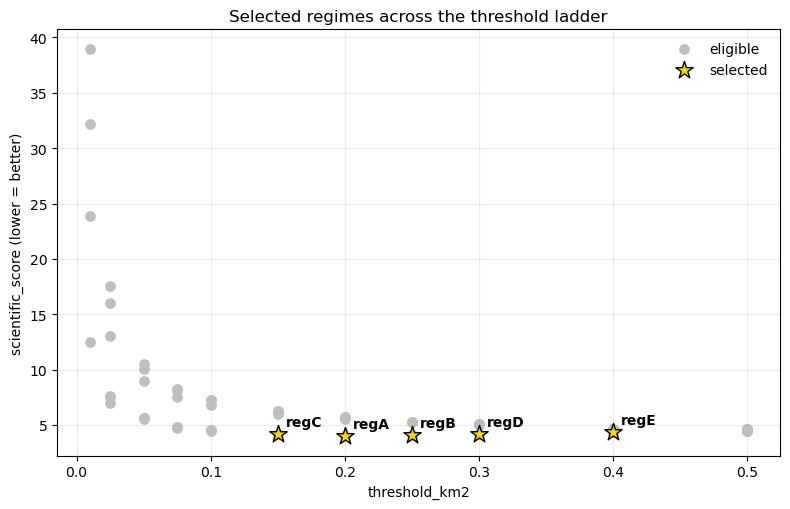

In [8]:
# Figure B — threshold ladder (eligible grey, selected gold+labelled).
fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.scatter(elig.threshold_km2, elig.scientific_score, s=45, c='0.75', label='eligible')
ax.scatter(top5.threshold_km2, top5.scientific_score, s=170, marker='*', facecolor='gold',
           edgecolor='k', zorder=5, label='selected')
for _, r in top5.iterrows():
    ax.annotate(r['name'], (r.threshold_km2, r.scientific_score),
                textcoords='offset points', xytext=(6, 6), fontsize=10, fontweight='bold')
ax.set_xlabel('threshold_km2'); ax.set_ylabel('scientific_score (lower = better)')
ax.set_title('Selected regimes across the threshold ladder')
ax.legend(frameon=False); ax.grid(True, alpha=0.25); fig.tight_layout()
fig.savefig(OPT_DIR / 'fig_selection_threshold_ladder.png', dpi=150, bbox_inches='tight'); plt.show()

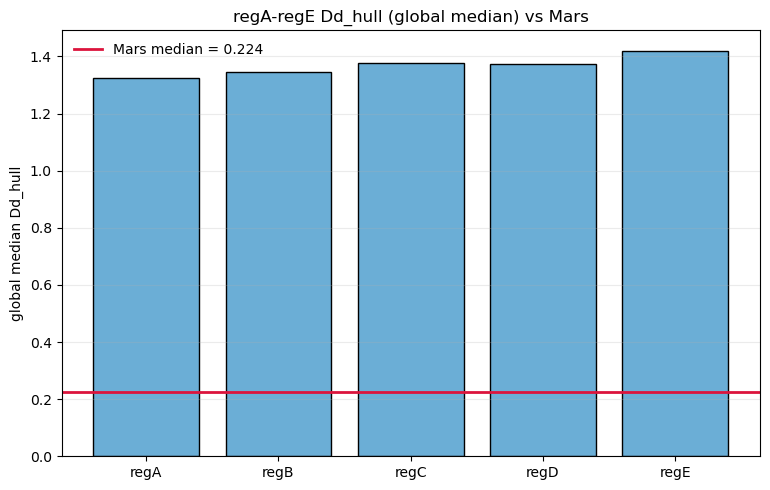

In [9]:
# Figure C — regA-regE global-median Dd_hull vs Mars target.
fig, ax = plt.subplots(figsize=(7.8, 5.0))
ax.bar(top5['name'], top5['earth_dd_hull_median'], color='#6baed6', edgecolor='k')
ax.axhline(MARS_DD_MEDIAN, color='crimson', lw=2, label=f'Mars median = {MARS_DD_MEDIAN:.3f}')
ax.set_ylabel('global median Dd_hull'); ax.set_title('regA-regE Dd_hull (global median) vs Mars')
ax.legend(frameon=False); ax.grid(True, axis='y', alpha=0.25); fig.tight_layout()
fig.savefig(OPT_DIR / 'fig_selection_ddhull_vs_mars.png', dpi=150, bbox_inches='tight'); plt.show()

### 3a · Verification — why regA–regE are plain `trim` (not `trim+delta`, not higher trim)

Plain `trim` (remove order 1) beating `trim+delta` is **threshold-dependent**, and worth checking rather than assuming:

- **At low thresholds (≲ 0.10 km²)** the network is dense and high-order, so the delta (order-gap) rule fires and *lowers* median Dd_hull toward Mars — there `trim_d3` actually **wins**.
- **At the selected thresholds (0.15–0.40 km²)** the once-trimmed network's order span is already small, so delta fires on almost nothing: it leaves **median Dd_hull and complexity identical** and only shaves a little length → it can only *lose*. There plain `trim` **strictly dominates** `trim+delta`.

regA–regE land in that higher-threshold neighbourhood because the low thresholds (even delta-improved) stay far denser than Mars overall. **Higher trimming (`ge3` = remove order 1+2)** is excluded everywhere — it falls below the 30% length floor (over-pruned).

> **Caveat (metric).** This uses **median** Dd_hull, which is insensitive to delta at these thresholds; per *individual basin* delta does reduce Dd_hull (see the archived `regime/03` VN drawing). A per-basin / in-IQR Mars-match metric would credit delta — switch metrics if delta's basin-level effect should drive selection.

In [10]:
# Verify: plain trim vs trim+delta at every threshold + higher-trim (ge3) eligibility.
_fam = candidates[candidates.pruning_variant.isin(['trim', 'trim_d3', 'trim_d4'])]
_sci = _fam.pivot(index='threshold_km2', columns='pruning_variant', values='scientific_score')
_dd = _fam.pivot(index='threshold_km2', columns='pruning_variant', values='earth_dd_hull_median')
_len = candidates[candidates.pruning_variant == 'trim'].set_index('threshold_km2')['length_retained_median']
vtab = pd.DataFrame({'trim': _sci['trim'], 'trim_d4': _sci['trim_d4'], 'trim_d3': _sci['trim_d3']})
vtab['winner'] = vtab[['trim', 'trim_d4', 'trim_d3']].idxmin(axis=1)
vtab['delta_changes_median_dd'] = ~(np.isclose(_dd['trim'], _dd['trim_d3'])
                                    & np.isclose(_dd['trim'], _dd['trim_d4']))
vtab['trim_len_ret'] = _len
display(vtab.round(4))

sel_thr = sorted(top5.threshold_km2.unique())
sel = vtab.loc[vtab.index.isin(sel_thr)]
print('selected regime thresholds   :', sel_thr)
print('plain trim wins at ALL selected thresholds :', bool((sel['winner'] == 'trim').all()))
print('thresholds where a delta variant wins      :', list(vtab[vtab.winner != 'trim'].index),
      '(low-T, not competitive overall)')
_ge3 = candidates[candidates.pruning_variant == 'ge3']
print(f'higher trim ge3 (remove order 1+2): median length_retained='
      f'{_ge3.length_retained_median.median():.2f}  eligible anywhere={bool(_ge3.eligible.any())} '
      f'(< 0.30 floor => over-pruned)')

,trim,trim_d4,trim_d3,winner,delta_changes_median_dd,trim_len_ret
threshold_km2,,,,,,
0.010,12.4782,11.7540,10.1146,trim_d3,True,0.3074
0.025,7.5830,7.5533,6.9627,trim_d3,True,0.3930
0.050,5.6740,5.6572,5.5165,trim_d3,True,0.4542
0.075,4.8166,4.8170,4.7657,trim_d3,True,0.4776
0.100,4.5189,4.5193,4.4612,trim_d3,True,0.4862
0.150,4.1676,4.1679,4.1688,trim,False,0.4959
0.200,3.9858,3.9860,3.9871,trim,False,0.4978
0.250,4.0893,4.0895,4.0904,trim,False,0.4921
0.300,4.1875,4.1878,4.1885,trim,False,0.4940


selected regime thresholds   : [np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.4)]
plain trim wins at ALL selected thresholds : True
thresholds where a delta variant wins      : [0.01, 0.025, 0.05, 0.075, 0.1] (low-T, not competitive overall)
higher trim ge3 (remove order 1+2): median length_retained=0.24  eligible anywhere=False (< 0.30 floor => over-pruned)


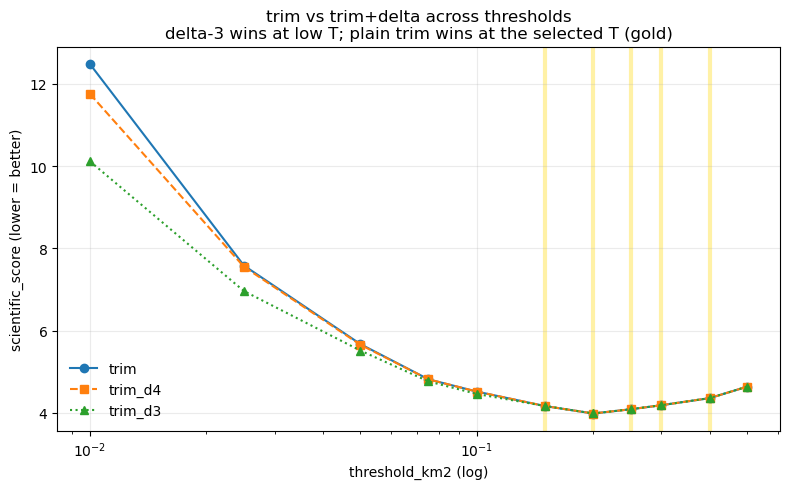

In [11]:
# Figure — scientific_score vs threshold for the trim family (delta wins low-T; trim wins at selected T).
fig, ax = plt.subplots(figsize=(8.0, 5.0))
for v, ls, mk in [('trim', '-', 'o'), ('trim_d4', '--', 's'), ('trim_d3', ':', '^')]:
    ax.plot(_sci.index, _sci[v], ls, marker=mk, label=v)
for t in sel_thr:
    ax.axvline(t, color='gold', alpha=0.35, lw=3, zorder=0)
ax.set_xscale('log'); ax.set_xlabel('threshold_km2 (log)')
ax.set_ylabel('scientific_score (lower = better)')
ax.set_title('trim vs trim+delta across thresholds\n'
             'delta-3 wins at low T; plain trim wins at the selected T (gold)')
ax.legend(frameon=False); ax.grid(True, alpha=0.25); fig.tight_layout()
fig.savefig(OPT_DIR / 'fig_trim_vs_delta_verification.png', dpi=150, bbox_inches='tight'); plt.show()

**Selection takeaway.** regA–regE are the top-5 distinct, eligibility-passing regimes by `scientific_score`, written to `selected_regimes_AE.csv` and loadable via `channel_heads.regimes.load_selected_regimes`. Scores are robust **medians across all basins** (not any single basin).

**Downstream migration (in progress).** The frozen `channel_heads.regimes.REGIMES` (regA/regB/regC) have been updated to the **top-3** of this ranking (T=0.20/0.25/0.15 km², plain `trim`). The `*_reg{A,B,C}` CNN/XGBoost/thresholds + Mars predictions are being regenerated on those definitions (the prior artifacts were trained on the old hand-frozen presets and do not match); regime inference is valid only once that retrain completes.